# Player Tracking in Sports - Multi-View Tracking and 3D Reconstruction

### Imports

In [ ]:
from src.utils.video import open_video, get_frames
from src.utils.visualization import show_images, show_detection_table, show_identity_table, show_hota_table
from src.utils.model_loading import load_fine_tuned_yolo_model
from src.utils.annotations.download_annotations import download_annotations
from src.utils.annotations.load_annotations import load_annotations

from src.types.tracking import merge_detections

from src.detection.mog2_detection import run_mog2_detection, mog2_to_detection_output
from src.detection.yolo_detection import run_yolo_detection, yolo_to_detection_output
from src.tracking.sort import apply_sort
from src.tracking.deep_sort import apply_deep_sort
from src.detection.nms import class_independent_nms
from src.tracking.label_resolution import resolve_track_labels

from src.evaluation.evaluate_tracking import evaluate_tracking, evaluate_detection

from collections import defaultdict
import cv2
import time
import os
from pathlib import Path
from dotenv import load_dotenv
from ultralytics import YOLO

In [2]:
CURRENT_CAMERA_ID = "cam_13"

### Path Definitions

In [3]:
VIDEOS_DIR = "data/videos"
CAMERA_SETTINGS_DIR = "data/camera_settings"
MODELS_DIR = "models/"
FINE_TUNED_MODELS_DIR = f"{MODELS_DIR}/fine_tuned_models"
ANNOTATIONS = "data/annotations/tracking_01"

# Define fundamental paths for each camera
CAMERAS = {
    "cam_13": {
        "video_path": f"{VIDEOS_DIR}/out13.mp4",
        "camera_settings": f"{CAMERA_SETTINGS_DIR}/cam13_settings.json",
    },
    "cam_2": {
        "video_path": f"{VIDEOS_DIR}/out2.mp4",
        "camera_settings": f"{CAMERA_SETTINGS_DIR}/cam2_settings.json",
    },
    "cam_4": {
        "video_path": f"{VIDEOS_DIR}/out4.mp4",
        "camera_settings": f"{CAMERA_SETTINGS_DIR}/cam4_settings.json",
    },
}

### Open Video and Read Frames

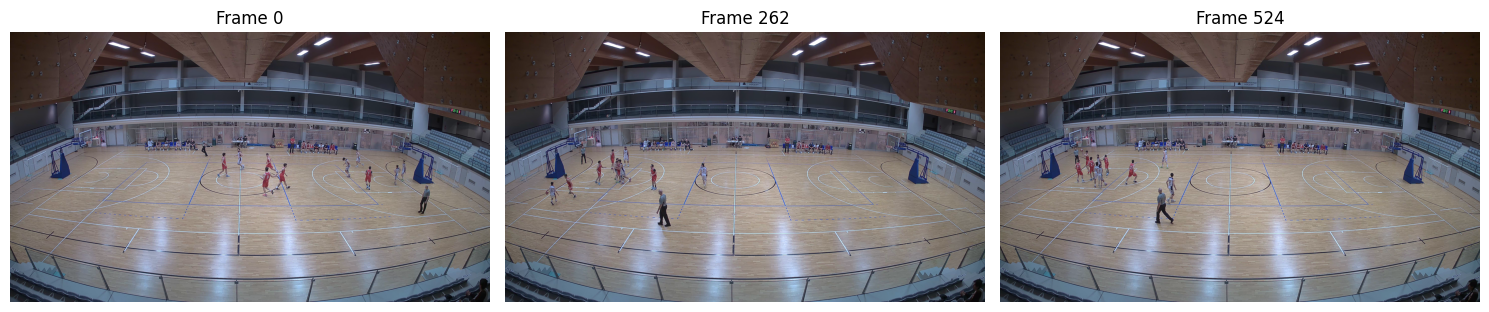

In [4]:
# Currently just one camera
cap = open_video(CAMERAS[CURRENT_CAMERA_ID]["video_path"])
frames_color, _ = get_frames(cap)
fps = cap.get(cv2.CAP_PROP_FPS)

# Release the video capture object to free resources
cap.release()

show_images(frames_color)

---

# Detection 

---

## Background Subtraction with MOG2 for Player Detection

> Manafifard, M., Ebadi, H., & Abrishami Moghaddam, H. (2017). A survey on player tracking in soccer videos. *Computer Vision and Image Understanding*, 159, 19–46. [`survey`]

We use the MOG2 (Mixture of Gaussians v2) background subtractor to detect moving players in each frame.
As a background subtraction method, MOG2 resulted as a good choice for our application and through various experiments with other methods.

We further improved the detection results by applying pre-processing steps and post-processing steps to the frames and the foreground masks, respectively.


For **pre-processing**, we applied a illumination normalization technique called **CLAHE (Contrast Limited Adaptive Histogram Equalization)** to enhance the contrast of the frames, which helps in better foreground detection. Then to limit the noise generated from the shadow generated from the high reflective surfaces in the field, we removed from the detection mask the pixels that correspond to the hue values of the field.

For **post-processing**, we applied morphological operations such as opening and closing to remove noise and fill holes in the detected foreground masks, and then we applied contour detection to extract the bounding boxes of the detected players. We removed small contours that are likely to be noise by filtering based on contour area.

### Parameters

We used as default parameters for the MOG2 background subtractor, the one that we found to be the best through fine-tuning and experimentation.

This function outputs a list of bounding boxes for each frame, where each bounding box corresponds to a detected player. Each bounding box is represented as a tuple of (x, y, width, height).

In [5]:
MOG2_LEARNING_RATE  = -1        # -1 lets OpenCV adapt the learning rate automatically
MOG2_HISTORY        = 1000      # number of frames used to model the background
MOG2_VAR_THRESHOLD  = 25        # Mahalanobis distance threshold for foreground/background decision
MOG2_OPENING_KERNEL = 7         # morphological opening kernel size (noise removal)
MOG2_CLOSING_KERNEL = 11        # morphological closing kernel size (hole filling)
MOG2_MIN_AREA       = 1500      # minimum contour area to keep (px²)
MOG2_MAX_AREA       = 200_000   # maximum contour area to keep (px²)

Processing 525 frames with MOG2 detection...
  Processed 100/525 frames (1.5 fps)
  Processed 200/525 frames (1.5 fps)
  Processed 300/525 frames (1.5 fps)
  Processed 400/525 frames (1.5 fps)
  Processed 500/525 frames (1.5 fps)
Done in 360.0s — 3921 detections across 525 frames


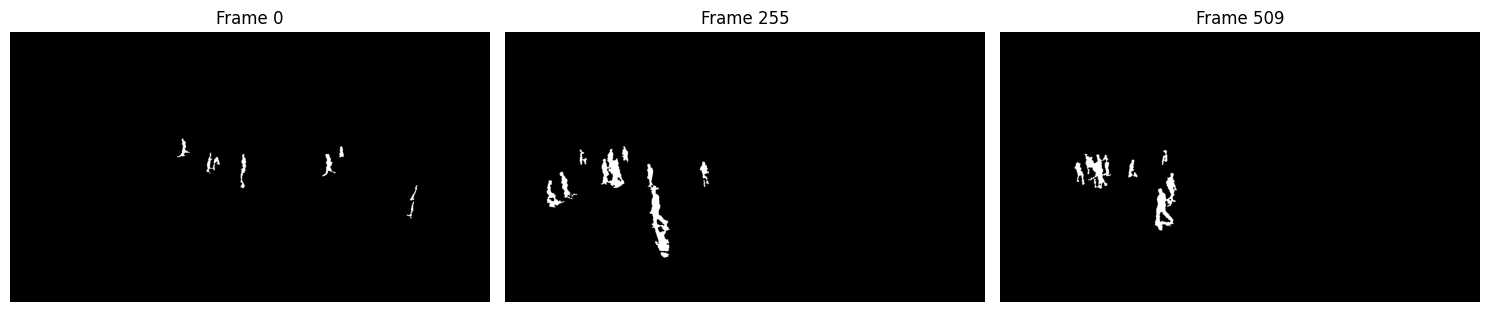

In [6]:
print(f"Processing {len(frames_color)} frames with MOG2 detection...")
start_time = time.time()

mog2_masks = run_mog2_detection(
    frames_color,
    learning_rate=MOG2_LEARNING_RATE,
    history_length=MOG2_HISTORY,
    var_threshold=MOG2_VAR_THRESHOLD,
    opening_kernel_size=MOG2_OPENING_KERNEL,
    closing_kernel_size=MOG2_CLOSING_KERNEL,
    min_area=MOG2_MIN_AREA,
    max_area=MOG2_MAX_AREA,
)
elapsed = time.time() - start_time

mog2_detection_output = mog2_to_detection_output(mog2_masks, camera_id=CURRENT_CAMERA_ID, fps=fps)

n_dets = sum(f.num_detections for f in mog2_detection_output.frames)
print(f"Done in {elapsed:.1f}s — {n_dets} detections across {len(mog2_detection_output.frames)} frames")

# Show raw masks (skip the first warm-up frames — MOG2 needs time to learn the background)
show_images(mog2_masks[15:])

### Inspect MOG2 Detections

We visualize the MOG2 blob detected by outputting the binary mask.
This allows us to inspect the quality of the foreground detection and to tune the parameters of the MOG2 background subtractor and the post-processing steps accordingly.

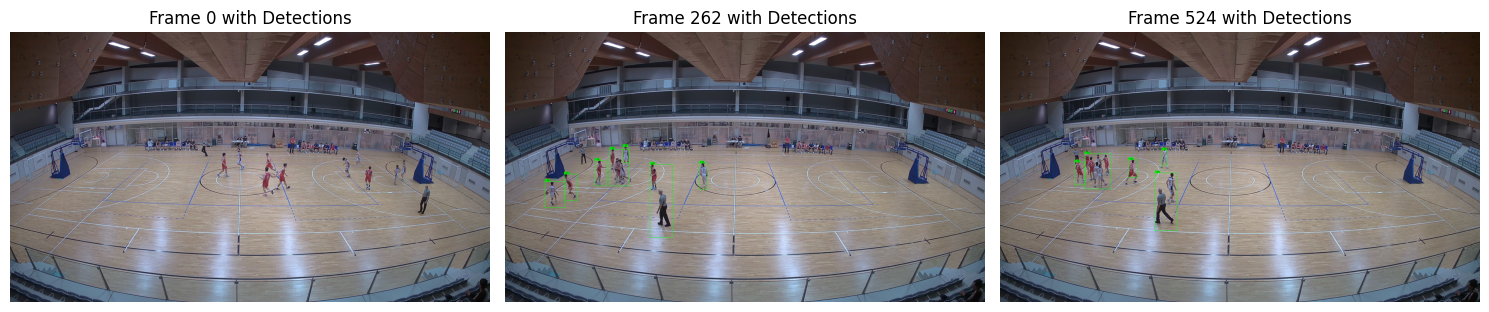

Annotations already present in data/annotations/tracking_01 — skipping download.
Loaded ground truth: 1408 annotations across 105 frames


ValueError: Detection evaluation: frame index mismatch. GT len/range=105/0..104, pred len/range=525/0..524. GT-only sample=[], pred-only sample=[105, 106, 107, 108, 109].

In [ ]:
show_images(frames_color, mog2_detection_output)

# Download annotations if not already present
if not any(Path(ANNOTATIONS).glob("*.json")):
    load_dotenv()
    api_key = os.environ["ANNOTATIONS_API_KEY"]
    download_annotations("tracking-rybv7", "tracking_01", 1, api_key, ANNOTATIONS)
else:
    print(f"Annotations already present in {ANNOTATIONS} — skipping download.")

ground_truth = load_annotations(camera_id=CURRENT_CAMERA_ID, version="tracking_01")
print(f"Loaded ground truth: {sum(len(f.detections) for f in ground_truth.frames)} annotations across {len(ground_truth.frames)} frames")
mog2_detection_metrics = evaluate_detection(ground_truth, mog2_detection_output)
show_detection_table({"MOG2": mog2_detection_metrics})

---

## Pre-Trained YOLOv11

> Jocher, G., Qiu, J., & Chaurasia, A. (2023). Ultralytics YOLO. [`yolo`]

We use a deep learning-based object detection model, YOLOv11, to detect players in each frame. This can be done by loading a pre-trained YOLOv11 model and running inference on the frames to get bounding boxes for detected players.

### Parameters

In [ ]:
YOLO_PRETRAINED_CONF = 0.4    # confidence threshold
YOLO_PRETRAINED_IOU  = 0.45   # IoU threshold for built-in NMS
YOLO_PRETRAINED_SIZE = 640    # inference image size

### Run YOLO Detection on All Frames

Use YOLOv11's built-in `.predict()` method to detect objects in each frame. The output will include bounding boxes, confidence scores, and class labels for each detected object.

**Output per frame:**
- Bounding boxes: `[x1, y1, x2, y2]` (pixel coordinates)
- Confidence scores: Detection confidence (0–1)
- Class labels: What was detected (e.g., "person", "sports_ball")

In [ ]:
print(f"Processing {len(frames_color)} frames with pre-trained YOLO detection...")
start_time = time.time()

yolo_pretrained_raw = run_yolo_detection(
    yolo_pretrained_model, frames_color,
    conf_threshold=YOLO_PRETRAINED_CONF,
    iou_threshold=YOLO_PRETRAINED_IOU,
    inference_size=YOLO_PRETRAINED_SIZE,
)

elapsed = time.time() - start_time
print(f"Done in {elapsed:.1f}s — {sum(len(r.boxes) for r in yolo_pretrained_raw)} raw detections")

In [ ]:
yolo_pretrained_detection_output = yolo_to_detection_output(
    yolo_pretrained_raw, yolo_pretrained_model,
    camera_id=CURRENT_CAMERA_ID, fps=fps, source="yolo_v11m_pt",
)

n_dets = sum(f.num_detections for f in yolo_pretrained_detection_output.frames)
print(f"Total detections after conversion: {n_dets} across {len(yolo_pretrained_detection_output.frames)} frames")

In [ ]:
print(f"First frame detections: {yolo_pretrained_detection_output.frames[0].num_detections} objects detected")
for i, det in enumerate(yolo_pretrained_detection_output.frames[0].detections[:5]):
    print(f"  Detection {i+1}: Class={det.class_name}, Confidence={det.confidence:.2f}, BBox={det.bbox}")

show_images(frames_color, yolo_pretrained_detection_output)

---

## Fine-Tuned YOLOv11

> Jocher, G., Qiu, J., & Chaurasia, A. (2023). Ultralytics YOLO. [`yolo`]

We fine-tuned a YOLOv11m model on our annotated dataset to detect players with identity labels (e.g. `Red_11`, `White_7`) and the ball as separate classes. A two-pass inference strategy is used: a standard-resolution pass for players and a high-resolution pass for the ball.

Let's check the labels in the model to ensure they match our dataset's classes. This is crucial for accurate training and inference.

### Parameters

In [ ]:
yolo_finetuned_model = load_fine_tuned_yolo_model()

In [ ]:
YOLO_FINETUNED_PLAYER_CONF = 0.3    # confidence threshold for player pass
YOLO_FINETUNED_BALL_CONF   = 0.1    # lower threshold for ball (small object, favour recall)
YOLO_FINETUNED_PLAYER_SIZE = 640    # inference size for player pass
YOLO_FINETUNED_BALL_SIZE   = 1280   # higher resolution for ball pass

In [ ]:
yolo_finetuned_model.names

### Run Fine-Tuned YOLO Detection on All Frames

In [ ]:
print(f"Processing {len(frames_color)} frames with fine-tuned YOLO (player detection pass)...")
start_time = time.time()

# Pass 1 — all players at standard resolution
yolo_finetuned_player_raw = run_yolo_detection(
    yolo_finetuned_model,
    frames_color,
    conf_threshold=YOLO_FINETUNED_PLAYER_CONF,
    inference_size=YOLO_FINETUNED_PLAYER_SIZE,
    class_ids=list(range(1, len(yolo_finetuned_model.names))),  # exclude ball (class 0)
)

elapsed = time.time() - start_time
print(f"Done in {elapsed:.1f}s — {sum(len(r.boxes) for r in yolo_finetuned_player_raw)} player detections")

### Higher-Resolution Pass — Ball Only

The football is a small object (~10–20 px in match footage) and the standard 640-px inference grid struggles to localize it. We therefore run a **second** inference pass at higher `imgsz` (1280) with a lower confidence threshold.

Critically, this pass is **class-filtered to the ball only**. Running high-resolution inference for `person` would also surface tiny bench players and spectators in the stands — exactly what we don't want.

In [ ]:
print(f"Processing {len(frames_color)} frames with fine-tuned YOLO (ball pass)...")
start_time = time.time()

# Pass 2 — ball only at high resolution
# class_ids=[0] is the ball label in the fine-tuned model
yolo_finetuned_ball_raw = run_yolo_detection(
    yolo_finetuned_model, frames_color,
    conf_threshold=YOLO_FINETUNED_BALL_CONF,
    inference_size=YOLO_FINETUNED_BALL_SIZE,
    class_ids=[0],
)

elapsed = time.time() - start_time
print(f"Done in {elapsed:.1f}s — {sum(len(r.boxes) for r in yolo_finetuned_ball_raw)} ball detections")

### Merge Player and Ball Detections

Combine both passes into a single `DetectionOutput`, frame by frame. After fine-tuning, only the `class_ids` lists in the two passes above need to change — the merge stays identical.

In [ ]:
yolo_finetuned_player_out = yolo_to_detection_output(
    yolo_finetuned_player_raw, yolo_finetuned_model,
    camera_id=CURRENT_CAMERA_ID, fps=fps, source="yolo_v11m_ft",
)
yolo_finetuned_ball_out = yolo_to_detection_output(
    yolo_finetuned_ball_raw, yolo_finetuned_model,
    camera_id=CURRENT_CAMERA_ID, fps=fps, source="yolo_v11m_ft",
)

yolo_finetuned_merged_output = merge_detections(yolo_finetuned_player_out, yolo_finetuned_ball_out)

n_merged = sum(f.num_detections for f in yolo_finetuned_merged_output.frames)
print(f"Merged: {n_merged} detections across {len(yolo_finetuned_merged_output.frames)} frames")

### Inspect Merged Detections

In [ ]:
print(f"First frame detections: {yolo_finetuned_merged_output.frames[0].num_detections} objects detected")
for i, det in enumerate(yolo_finetuned_merged_output.frames[0].detections[:5]):
    print(f"  Detection {i+1}: Class={det.class_name}, Confidence={det.confidence:.2f}, BBox={det.bbox}")

show_images(frames_color, yolo_finetuned_merged_output)

### Class-Agnostic NMS

> Neubeck, A., & Van Gool, L. (2006). Efficient non-maximum suppression. *ICPR'06*, Vol. 3, 850–855. [`nms`]

YOLO does NMS only within each class. Our identity-encoded labels (`Red_5`, `Red_11`, …) make this insufficient: two boxes for the same physical player but different predicted identities both survive, then spawn parallel tracks in DeepSORT. We collapse them with a single class-agnostic greedy NMS pass before tracking — for each frame, sort detections by confidence and keep a box only if it doesn't overlap an already-kept box above the IoU threshold.

In [ ]:
NMS_IOU_THRESHOLD = 0.5    # IoU above which a lower-confidence box is suppressed

In [ ]:
before = sum(len(f.detections) for f in yolo_finetuned_merged_output.frames)
yolo_finetuned_detection_output = class_independent_nms(yolo_finetuned_merged_output, iou_threshold=NMS_IOU_THRESHOLD)
after = sum(len(f.detections) for f in yolo_finetuned_detection_output.frames)
print(f"Class-agnostic NMS: {before} → {after} detections ({before - after} suppressed)")

In [ ]:
show_images(frames_color, yolo_finetuned_detection_output)

---

# Tracking

---

## SORT Tracking

> Bewley, A., Ge, Z., Ott, L., Ramos, F., & Upcroft, B. (2016). Simple online and realtime tracking. *ICIP 2016*, 3464–3468. [`sort`]

SORT (Simple Online and Realtime Tracking) assigns a stable `track_id` to each detection using a **Kalman filter** for motion prediction and the **Hungarian algorithm** for IoU-based assignment. It operates with no appearance features — only bounding box overlap.

### Parameters

In [ ]:
SORT_MAX_IOU_DISTANCE = 0.8   # IoU gating threshold for Kalman-prediction-to-detection assignment
SORT_MAX_AGE          = 60    # frames a track stays alive while unmatched (~2.4 s at 25 fps)
SORT_N_INIT           = 2     # consecutive matches required before a track is confirmed

In [ ]:
print(f"Running SORT on {len(yolo_finetuned_detection_output.frames)} frames...")
start_time = time.time()

sort_tracking_output = apply_sort(
    yolo_finetuned_detection_output,
    max_iou_distance=SORT_MAX_IOU_DISTANCE,
    max_age=SORT_MAX_AGE,
    n_init=SORT_N_INIT,
)

elapsed = time.time() - start_time
total_tracks = len({d.track_id for f in sort_tracking_output.frames for d in f.detections})
total_dets   = sum(len(f.detections) for f in sort_tracking_output.frames)
print(f"Done in {elapsed:.1f}s — {total_tracks} tracks across {total_dets} tracked detections")

In [ ]:
show_images(frames_color, sort_tracking_output)

### Resolve Per-Track Labels

YOLO's class names already encode identity (e.g. `Red_11` = Red team #11), but the model occasionally flips a player's label between frames or returns two boxes with the same class in one frame. We use the track ids assigned above to vote for a stable label per track and resolve collisions where two tracks claim the same identity.

The track with the highest cumulative confidence keeps its top-choice label; any other track that wanted that label falls through to its next-best class. `Ball` is exempt — it's a category, not a unique identity.

In [ ]:
sort_resolved_output = resolve_track_labels(sort_tracking_output)

per_track_label = defaultdict(set)
for fd in sort_resolved_output.frames:
    for d in fd.detections:
        per_track_label[d.track_id].add(d.class_name)

multi_label = [tid for tid, labels in per_track_label.items() if len(labels) > 1]
print(f"Tracks with a single stable label: {len(per_track_label) - len(multi_label)} / {len(per_track_label)}")
if multi_label:
    print(f"Tracks still showing multiple labels (should only be Ball): {multi_label}")
for tid, labels in sorted(per_track_label.items()):
    print(f"  track {tid:>3}: {sorted(labels)}")

In [ ]:
show_images(frames_color, sort_resolved_output)

---

## Tracking with DeepSORT

> Wojke, N., Bewley, A., & Paulus, D. (2017). Simple online and realtime tracking with a deep association metric. *arXiv:1703.07402*. [`deepsort`]
>
> Zhou, K., Yang, Y., Cavallaro, A., & Xiang, T. (2019). Omni-Scale Feature Learning for Person Re-Identification. *arXiv:1905.00953*. [`reid`]

The fine-tuned model gives us solid per-frame detections, but each frame is independent — there's no notion of identity across time. We pipe the merged detections through our DeepSORT implementation (IoU + Kalman filter + appearance ReID) so each player gets a stable `track_id` that persists frame-to-frame, surviving short occlusions up to `max_age` frames.

The tracker is intentionally class-agnostic: a track can absorb mislabeled observations across frames, which the next step will use to recover a single stable label per track.

### Parameters

In [ ]:
# Tuning notes for sports footage at 25 fps:
#   max_age:                 frames a track stays alive while unmatched before being
#                            killed. 30 ≈ 1.2 s of occlusion tolerance — too short for
#                            football where players cross for 2–3 s. We use 60 (≈ 2.4 s).
#   max_iou_distance:        IoU gating. Looser (0.8) tolerates more Kalman drift over
#                            longer gaps; too loose causes id swaps between nearby players.
#   max_appearance_distance: cosine distance gate for the OSNet appearance feature.
#   n_init:                  frames a tentative track must match before being CONFIRMED.
DEEPSORT_MAX_IOU_DISTANCE        = 0.8   # IoU gating. Looser (0.8) tolerates more Kalman drift over
DEEPSORT_MAX_APPEARANCE_DISTANCE = 0.2   # cosine distance threshold for appearance-based matching (lower = stricter, 0.2 is a common default)
DEEPSORT_MAX_AGE                 = 60    # frames a track stays alive while unmatched before being killed. 30 ≈ 1.2 s of occlusion tolerance — too short for football where players cross for 2–3 s. We use 60 (≈ 2.4 s).
DEEPSORT_N_INIT                  = 2     # consecutive matches required before a track is confirmed
DEEPSORT_FEATURE_BUDGET          = 100   # max appearance features stored per track

In [ ]:
print(f"Running DeepSORT on {len(yolo_finetuned_detection_output.frames)} frames...")
start_time = time.time()

deepsort_tracking_output = apply_deep_sort(
    yolo_finetuned_detection_output,
    frames=frames_color,
    max_iou_distance=DEEPSORT_MAX_IOU_DISTANCE,
    max_appearance_distance=DEEPSORT_MAX_APPEARANCE_DISTANCE,
    max_age=DEEPSORT_MAX_AGE,
    n_init=DEEPSORT_N_INIT,
    feature_budget=DEEPSORT_FEATURE_BUDGET,
)

elapsed = time.time() - start_time
total_tracks = len({d.track_id for f in deepsort_tracking_output.frames for d in f.detections})
total_dets   = sum(len(f.detections) for f in deepsort_tracking_output.frames)
print(f"Done in {elapsed:.1f}s — {total_tracks} tracks across {total_dets} tracked detections")

In [ ]:
show_images(frames_color, deepsort_tracking_output)

### Resolve Per-Track Labels

YOLO's class names already encode identity (e.g. `Red_11` = Red team #11), but the model occasionally flips a player's label between frames or returns two boxes with the same class in one frame. We use the track ids assigned above to vote for a stable label per track and resolve collisions where two tracks claim the same identity.

The track with the highest cumulative confidence keeps its top-choice label; any other track that wanted that label falls through to its next-best class. `Ball` is exempt — it's a category, not a unique identity.

In [ ]:
deepsort_resolved_output = resolve_track_labels(deepsort_tracking_output)

per_track_label = defaultdict(set)
for fd in deepsort_resolved_output.frames:
    for d in fd.detections:
        per_track_label[d.track_id].add(d.class_name)

multi_label = [tid for tid, labels in per_track_label.items() if len(labels) > 1]
print(f"Tracks with a single stable label: {len(per_track_label) - len(multi_label)} / {len(per_track_label)}")
if multi_label:
    print(f"Tracks still showing multiple labels (should only be Ball): {multi_label}")
for tid, labels in sorted(per_track_label.items()):
    print(f"  track {tid:>3}: {sorted(labels)}")

In [ ]:
show_images(frames_color, deepsort_resolved_output)

---

# Evaluation

## Ground Truth

In [ ]:
# Download annotations if not already present
if not any(Path(ANNOTATIONS).glob("*.json")):
    load_dotenv()
    api_key = os.environ["ANNOTATIONS_API_KEY"]
    download_annotations("tracking-rybv7", "tracking_01", 1, api_key, ANNOTATIONS)
else:
    print(f"Annotations already present in {ANNOTATIONS} — skipping download.")

ground_truth = load_annotations(camera_id=CURRENT_CAMERA_ID, version="tracking_01")
print(f"Loaded ground truth: {sum(len(f.detections) for f in ground_truth.frames)} annotations across {len(ground_truth.frames)} frames")

## Detection

Detection metrics are computed at the bounding-box level, ignoring identity.

| Metric | Definition |
|--------|-----------|
| **TP** | Predicted boxes that match a ground-truth box (IoU ≥ 0.5) |
| **FP** | Predicted boxes with no matching ground-truth box |
| **FN** | Ground-truth boxes with no matching prediction |
| **Precision** | TP / (TP + FP) — how many detections are correct |
| **Recall** | TP / (TP + FN) — how many ground-truth boxes are found |
| **F1** | Harmonic mean of precision and recall |
| **Mean IoU** | Average overlap of matched pairs |

In [ ]:
mog2_detection_metrics           = evaluate_detection(ground_truth, mog2_detection_output)
yolo_pretrained_detection_metrics = evaluate_detection(ground_truth, yolo_pretrained_detection_output)
yolo_finetuned_detection_metrics  = evaluate_detection(ground_truth, yolo_finetuned_detection_output)

show_detection_table({
    "MOG2":               mog2_detection_metrics,
    "YOLO (pre-trained)": yolo_pretrained_detection_metrics,
    "YOLO (fine-tuned)":  yolo_finetuned_detection_metrics,
})

## Tracking

> Luiten, J., et al. (2020). HOTA: A Higher Order Metric for Evaluating Multi-object Tracking. *IJCV*, 129(2), 548–578. [`hota`]

Tracking evaluation uses three complementary metric families:

**Detection-level** (same as above): measures per-frame bounding box quality regardless of identity.

**Identity (IDF1)**: measures how consistently each ground-truth identity is assigned the same track id over time.

| Metric | Definition |
|--------|-----------|
| **IDTP** | GT detections correctly matched to the same predicted id |
| **IDFP** | Predicted detections matched to the wrong GT identity |
| **IDFN** | GT detections not matched by any consistent id |
| **IDF1** | 2·IDTP / (2·IDTP + IDFP + IDFN) |

**HOTA**: decomposes tracking quality into detection accuracy (DetA) and association accuracy (AssA).

| Metric | Definition |
|--------|-----------|
| **HOTA** | √(DetA × AssA) — geometric mean averaged over IoU thresholds |
| **DetA** | Detection accuracy at each IoU threshold |
| **AssA** | Association accuracy at each IoU threshold |
| **LocA** | Localisation accuracy of matched pairs |

In [ ]:
sort_tracking_result     = evaluate_tracking(ground_truth, sort_resolved_output)
deepsort_tracking_result = evaluate_tracking(ground_truth, deepsort_resolved_output)

In [ ]:
print("Detection-level metrics:")
show_detection_table({
    "SORT":     sort_tracking_result,
    "DeepSORT": deepsort_tracking_result,
})

In [ ]:
print("Identity metrics (IDF1):")
show_identity_table({
    "SORT":     sort_tracking_result,
    "DeepSORT": deepsort_tracking_result,
})

In [ ]:
print("HOTA metrics:")
show_hota_table({
    "SORT":     sort_tracking_result,
    "DeepSORT": deepsort_tracking_result,
})